In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [77]:
df = pd.read_csv("../../datasets/Liver_Patient_Dataset.csv", encoding='latin1')

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')

In [78]:
df['Gender_of_the_patient'] = df['Gender_of_the_patient'].map({
    'Male': 1,
    'Female': 0
})

In [131]:
df.isnull().sum()

Age_of_the_patient                      0
Gender_of_the_patient                   0
Total_Bilirubin                         0
Direct_Bilirubin                        0
Alkphos_Alkaline_Phosphotase            0
Sgpt_Alamine_Aminotransferase           0
Sgot_Aspartate_Aminotransferase         0
Total_Protiens                          0
ALB_Albumin                             0
A/G_Ratio_Albumin_and_Globulin_Ratio    0
Result                                  0
dtype: int64

In [132]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

In [133]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [134]:
X = df.drop(columns=['Result'])
y = df['Result']

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [136]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [137]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [138]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [139]:
svm = SVC(kernel='rbf', class_weight='balanced')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [140]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")

    # Weighted metrics (for imbalance)
    precision_w = precision_score(y_test, y_pred, average='weighted')
    recall_w = recall_score(y_test, y_pred, average='weighted')
    f1_w = f1_score(y_test, y_pred, average='weighted')

    # Class-specific (Disease = class 2)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=2)
    recall = recall_score(y_test, y_pred, pos_label=2)
    f1 = f1_score(y_test, y_pred, pos_label=2)

    print(f"Accuracy           : {acc:.4f}")
    print(f"Precision (class2) : {precision:.4f}")
    print(f"Recall (class2)    : {recall:.4f}")
    print(f"F1 Score (class2)  : {f1:.4f}")

    print("\nWeighted Metrics:")
    print(f"Precision (weighted): {precision_w:.4f}")
    print(f"Recall (weighted)   : {recall_w:.4f}")
    print(f"F1 Score (weighted) : {f1_w:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [141]:
from IPython.display import display
display(df)

,Age_of_the_patient,Gender_of_the_patient,Total_Bilirubin,Direct_Bilirubin,Alkphos_Alkaline_Phosphotase,Sgpt_Alamine_Aminotransferase,Sgot_Aspartate_Aminotransferase,Total_Protiens,ALB_Albumin,A/G_Ratio_Albumin_and_Globulin_Ratio,Result
0,65.0,0.0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,1.0,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,1.0,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,1.0,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,1.0,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
16384,58.0,1.0,2.9,1.3,482.0,22.0,34.0,7.0,2.4,0.50,1
16385,28.0,1.0,1.9,1.0,231.0,16.0,55.0,4.3,1.6,0.60,1
16386,50.0,1.0,2.2,1.0,610.0,17.0,28.0,7.3,2.6,0.55,1
16387,54.0,1.0,6.8,3.0,542.0,116.0,66.0,6.4,3.1,0.90,1


In [142]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)




Logistic Regression Results:
Accuracy           : 0.6281
Precision (class2) : 0.4189
Recall (class2)    : 0.8621
F1 Score (class2)  : 0.5639

Weighted Metrics:
Precision (weighted): 0.7729
Recall (weighted)   : 0.6281
F1 Score (weighted) : 0.6446

Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.54      0.68      2364
           2       0.42      0.86      0.56       914

    accuracy                           0.63      3278
   macro avg       0.66      0.70      0.62      3278
weighted avg       0.77      0.63      0.64      3278


Confusion Matrix:
 [[1271 1093]
 [ 126  788]]


In [143]:
evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest Results:
Accuracy           : 0.9994
Precision (class2) : 0.9978
Recall (class2)    : 1.0000
F1 Score (class2)  : 0.9989

Weighted Metrics:
Precision (weighted): 0.9994
Recall (weighted)   : 0.9994
F1 Score (weighted) : 0.9994

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      2364
           2       1.00      1.00      1.00       914

    accuracy                           1.00      3278
   macro avg       1.00      1.00      1.00      3278
weighted avg       1.00      1.00      1.00      3278


Confusion Matrix:
 [[2362    2]
 [   0  914]]


In [144]:
print(len(set(X_train.flatten()) & set(X_test.flatten())))

1027


In [145]:
evaluate_model("SVM", y_test, y_pred_svm)


SVM Results:
Accuracy           : 0.6565
Precision (class2) : 0.4449
Recall (class2)    : 0.9365
F1 Score (class2)  : 0.6032

Weighted Metrics:
Precision (weighted): 0.8143
Recall (weighted)   : 0.6565
F1 Score (weighted) : 0.6710

Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.55      0.70      2364
           2       0.44      0.94      0.60       914

    accuracy                           0.66      3278
   macro avg       0.70      0.74      0.65      3278
weighted avg       0.81      0.66      0.67      3278


Confusion Matrix:
 [[1296 1068]
 [  58  856]]


In [146]:
import numpy as np

y_random = np.random.permutation(y_test)
accuracy_score(y_test, y_random)

0.5924344112263575

In [147]:
df.duplicated().sum()

np.int64(0)

In [148]:
train_df = pd.DataFrame(X_train)
test_df = pd.DataFrame(X_test)

duplicates = pd.merge(train_df, test_df, how='inner')
print(len(duplicates))

2


In [149]:
from sklearn.utils import shuffle

# Shuffle labels
y_shuffled = shuffle(y_train, random_state=42)

rf = RandomForestClassifier()
rf.fit(X_train, y_shuffled)

y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Sanity Accuracy:", accuracy_score(y_test, y_pred))

Sanity Accuracy: 0.6082977425259305


In [150]:
import pandas as pd

importances = rf.feature_importances_
for col, val in zip(X.columns, importances):
    print(col, val)

Age_of_the_patient 0.6504000323936677
Gender_of_the_patient 0.06697893627455356
Total_Bilirubin 0.03045763477453298
Direct_Bilirubin 0.023343142929972548
Alkphos_Alkaline_Phosphotase 0.043677705952963865
Sgpt_Alamine_Aminotransferase 0.04121696228267674
Sgot_Aspartate_Aminotransferase 0.0438282736260934
Total_Protiens 0.037368547501549595
ALB_Albumin 0.03359730510383877
A/G_Ratio_Albumin_and_Globulin_Ratio 0.029131459160150835


In [151]:
df['Age_of_the_patient'].value_counts().head(10)

Age_of_the_patient
45.0    638
50.0    595
42.0    580
48.0    559
60.0    546
38.0    516
65.0    493
55.0    483
46.0    477
32.0    461
Name: count, dtype: int64

In [152]:
print(type(X_train))

<class 'numpy.ndarray'>


In [153]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X, y, cv=5)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.99969494 0.99969494 0.99938987 1.         0.99938969]
Mean CV Accuracy: 0.9996338858868633


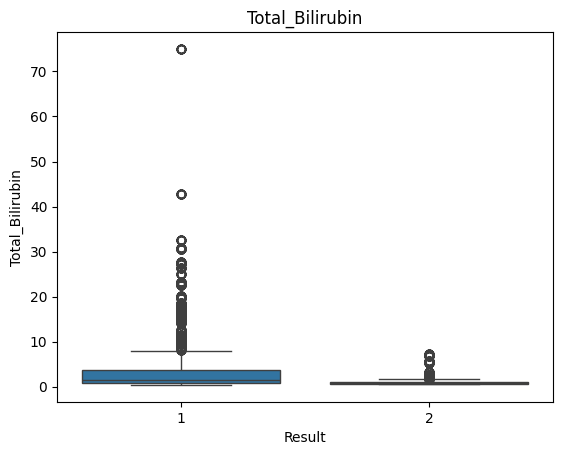

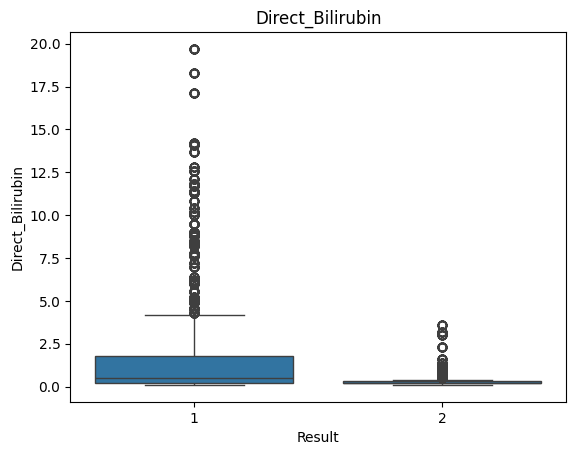

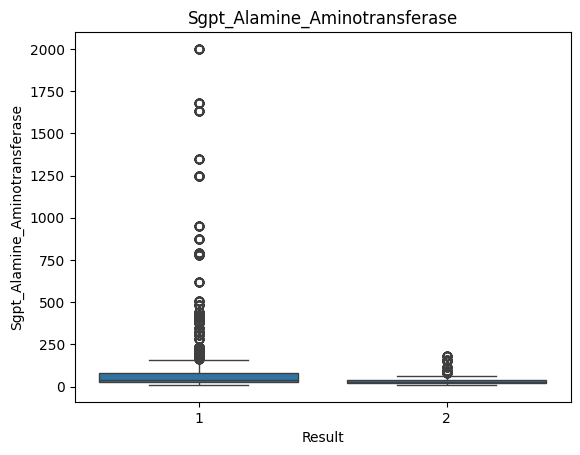

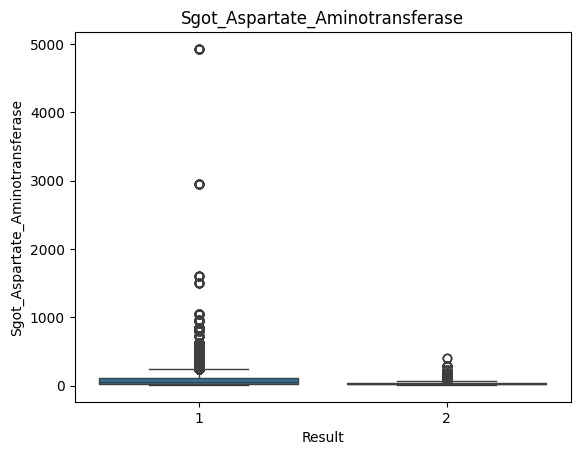

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Sgpt_Alamine_Aminotransferase',
    'Sgot_Aspartate_Aminotransferase'
]

for col in features:
    sns.boxplot(x='Result', y=col, data=df)
    plt.title(col)
    plt.show()

In [155]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))

Decision Tree Accuracy: 0.726052471018914


In [156]:
X_no_age = X.drop(columns=['Age_of_the_patient'])

from sklearn.model_selection import cross_val_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_no_age, y, cv=5)

print("New CV Accuracy:", scores.mean())

New CV Accuracy: 0.9997559115122445
